# National Level Analysis
Use statistical methods to determine correlations between water and electricity usage, and data center constructions over time. 

In [ ]:
# load data
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import ccf, adfuller

data = pd.read_pickle("../data/merged_state_data_2000_2020.pkl")

### Aggregate by Year

In [34]:
# aggregate by year 
datacenters_by_year = data.groupby('year').size().reset_index(name='datacenter_count')

national_df = data.groupby('year').agg({
    'electricity_usage': 'sum',
    'water_usage': 'sum'
}).reset_index()

national_df = (national_df
               .merge(datacenters_by_year, on='year', how='outer')
               .sort_values('year')
               .reset_index(drop=True))

national_df.head(5)

,year,electricity_usage,water_usage,datacenter_count
0,2000.0,3.311918e+09,1.482081e+06,244
1,2001.0,3.281284e+09,1.287594e+06,241
2,2002.0,3.359914e+09,7.115035e+05,213
3,2003.0,3.486925e+09,4.706102e+05,206
4,2004.0,3.540256e+09,5.536412e+05,209


### Plot Raw and Normalized Values

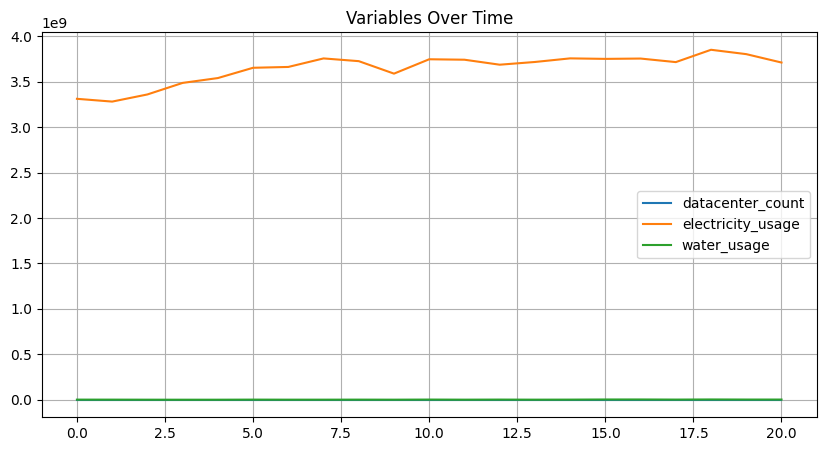

In [ ]:
national_df[['datacenter_count', 'electricity_usage', 'water_usage']].plot(figsize=(10,5))
plt.title('Variables Over Time')
plt.grid(True)
plt.show()

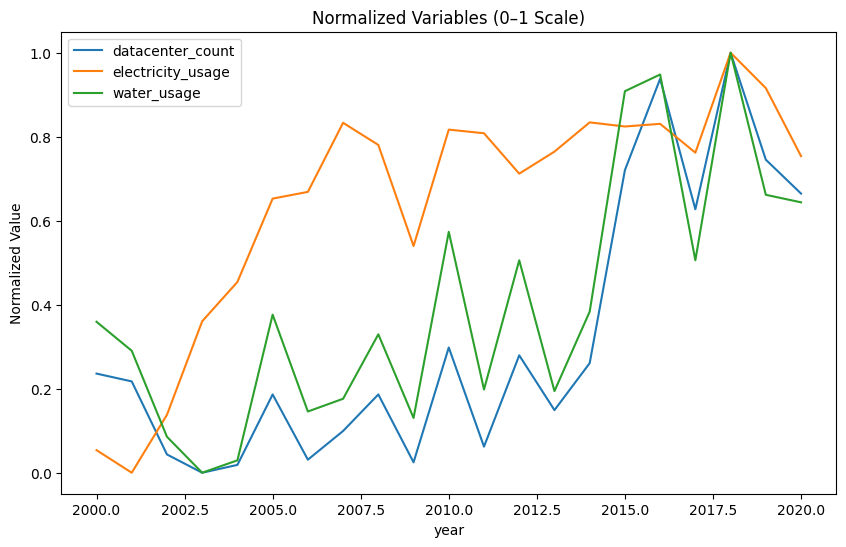

In [10]:
df_norm = national_df.copy()
cols = ['datacenter_count', 'electricity_usage', 'water_usage']

df_norm[cols] = (national_df[cols] - national_df[cols].min()) / (national_df[cols].max() - national_df[cols].min())

df_norm.plot(x='year', y=cols, figsize=(10,6))
plt.title('Normalized Variables (0–1 Scale)')
plt.ylabel('Normalized Value')
plt.show()

### Correlation Analysis

In [11]:
# correlation of growth rates
growth = national_df[cols].pct_change().dropna()
corr = growth.corr()
print(corr)

                   datacenter_count  electricity_usage  water_usage
datacenter_count           1.000000           0.369453     0.862884
electricity_usage          0.369453           1.000000     0.412664
water_usage                0.862884           0.412664     1.000000


In [ ]:
# log difference in correlation of growth rates 
log_growth = np.log(national_df[cols])
log_growth_diff = log_growth.diff().dropna()
log_growth_diff.corr()

,datacenter_count,electricity_usage,water_usage
datacenter_count,1.000000,0.375835,0.919225
electricity_usage,0.375835,1.000000,0.353856
water_usage,0.919225,0.353856,1.000000


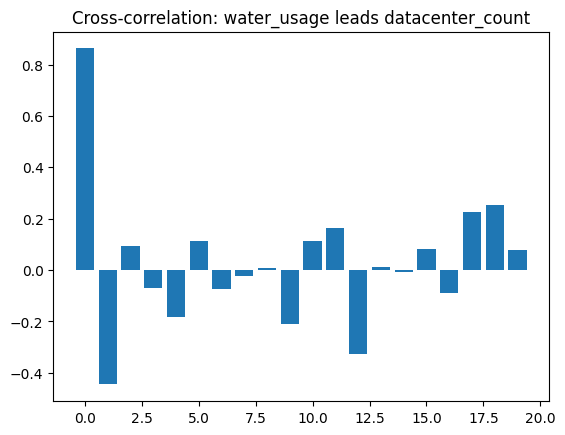

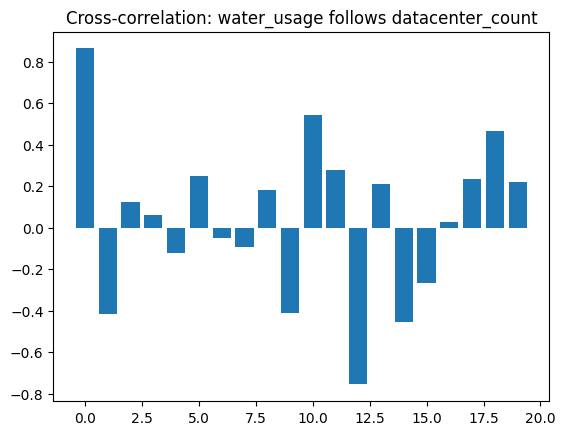

In [ ]:
# create loop for all vars + negative lags 
x = national_df['water_usage'].pct_change().dropna()
y = national_df['datacenter_count'].pct_change().dropna()

cross_corr = ccf(x, y)
plt.bar(range(20), cross_corr[:20])
plt.title(f"Cross-correlation: water_usage leads datacenter_count")
plt.show()

cross_corr = ccf(y, x)
plt.bar(range(20), cross_corr[:20])
plt.title(f"Cross-correlation: water_usage follows datacenter_count")
plt.show()

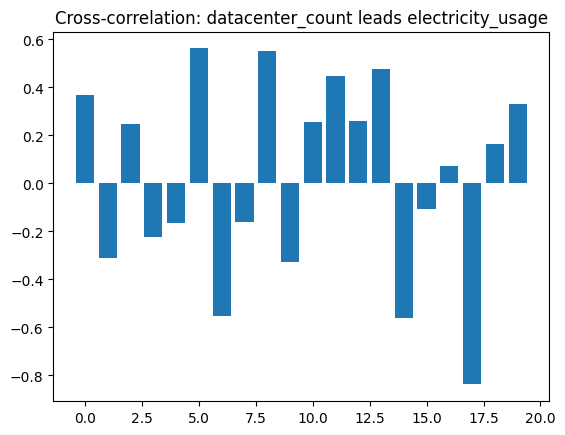

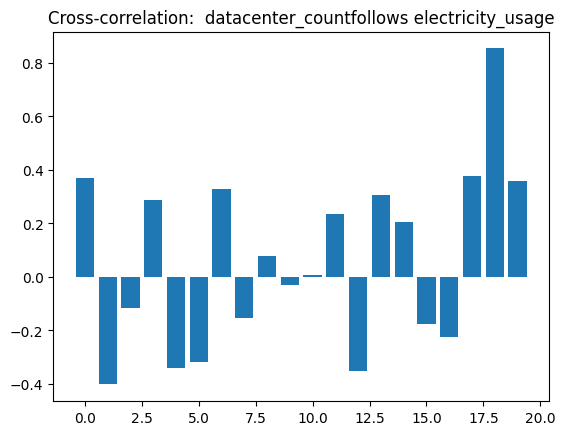

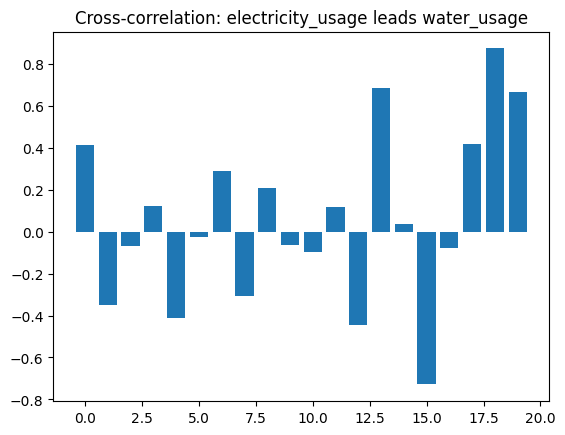

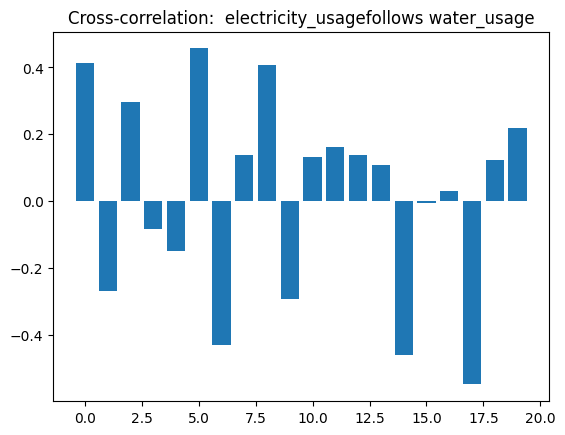

In [ ]:
# create loop for all vars + negative lags 
for col1, col2 in zip(cols, cols[1:]):
    x = national_df[col1].pct_change().dropna()
    y = national_df[col2].pct_change().dropna()

    cross_corr = ccf(x, y)
    plt.bar(range(20), cross_corr[:20])
    plt.title(f"Cross-correlation: {col1} leads {col2}")
    plt.show()

    cross_corr = ccf(y, x)
    plt.bar(range(20), cross_corr[:20])
    plt.title(f"Cross-correlation:  {col1} follows {col2}")
    plt.show()

### Forecasting

In [48]:
y = national_df['electricity_usage']
y_log = np.log(y)

adf_result = adfuller(y_log.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")

ADF Statistic: -1.1146, p-value: 0.7092


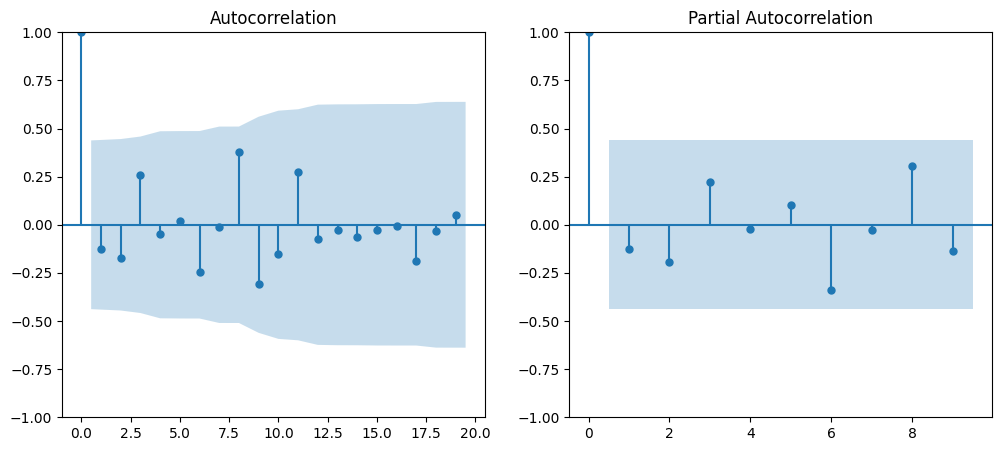

In [ ]:
# p-val > 0.05, needs differencing 
y_diff = y_log.diff().dropna()

y_diff.shape

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plt.subplot(121)
plot_acf(y_diff, ax=plt.gca(), lags=19)

plt.subplot(122)
plot_pacf(y_diff, ax=plt.gca(), lags=9)
plt.show()

In [47]:
from statsmodels.tsa.arima.model import ARIMA
d = 1
p = 1
q = 1

# Example: electricity usage
model = ARIMA(y_log, order=(p,d,q))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      electricity_usage   No. Observations:                   21
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  47.860
Date:                Tue, 03 Mar 2026   AIC                            -89.721
Time:                        20:11:21   BIC                            -86.734
Sample:                             0   HQIC                           -89.138
                                 - 21                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0167      6.919     -0.002      0.998     -13.578      13.545
ma.L1         -0.0168      6.897     -0.002      0.998     -13.534      13.501
sigma2         0.0005      0.000      2.517      0.0

c:\Users\dorky\anaconda3\envs\AD_450_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\dorky\anaconda3\envs\AD_450_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
